<a href="https://colab.research.google.com/github/Ouad90/Computer-Vision-Image-Classification-using-ResNet50/blob/main/Collab_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Computer Vision Project: CIFAR-10 Image Classification with ResNet50 Transfer Learning

## Project goal

The goal of this project is to build an end-to-end computer vision classification pipeline for the **CIFAR-10** dataset.

CIFAR-10 contains **60,000 RGB images** of size **32 × 32 × 3**, divided into **10 mutually exclusive classes**. The official project instructions ask us to use **10,000 training images**, keep the full **10,000-image test set**, preprocess the images, train a transfer-learning model using **ResNet50**, evaluate the model, and explain the choices made throughout the pipeline.

## What this notebook demonstrates

This notebook includes:

1. Dataset loading and sampling logic  
2. Image preprocessing steps  
3. Transfer learning with ResNet50  
4. Custom classification head  
5. Freezing and unfreezing training stages  
6. Training history visualizations  
7. Test-set evaluation  
8. Interpretation of results, limitations, and next steps  

The goal is not only to get accuracy, but to show understanding of the full workflow and the reasoning behind each decision.

## 1. Import libraries

We start by importing the tools needed for:

- loading CIFAR-10 from Keras
- preprocessing images for ResNet50
- building and training the model
- evaluating results
- plotting learning curves and examples

### Why these libraries were chosen

- **TensorFlow/Keras**: provides CIFAR-10, ResNet50, model layers, training tools, and evaluation tools.
- **NumPy**: handles arrays and numeric operations.
- **Pands**:
- **Matplotlib**: visualizes images and training curves.
- **Scikit-learn**: gives classification reports and confusion matrices.

In [ ]:
# If needed in Colab, uncomment this line:
# !pip install tensorflow scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 2. Load CIFAR-10

CIFAR-10 contains 60,000 RGB images of size **32 × 32 × 3**.

There are:
- 50,000 training images
- 10,000 test images
- 10 classes

In [ ]:
(train_images_full, train_labels_full), (test_images, test_labels) = cifar10.load_data()

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("Full training images:", train_images_full.shape)
print("Full training labels:", train_labels_full.shape)
print("Test images:", test_images.shape)
print("Test labels:", test_labels.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Full training images: (50000, 32, 32, 3)
Full training labels: (50000, 1)
Test images: (10000, 32, 32, 3)
Test labels: (10000, 1)


## 3. Choose training size

The project recommends starting with **10,000 training images** because training on all 50,000 can be slow in Colab.

To improve accuracy later, you can change:

```python
N_TRAIN = 50_000
```

Using more data is one of the most reliable ways to improve final test accuracy.

In [ ]:
N_TRAIN = 10_000  # Change to 50_000 if Colab runtime allows it

train_images = train_images_full[:N_TRAIN]
train_labels = train_labels_full[:N_TRAIN]

print("Selected training images:", train_images.shape)
print("Selected training labels:", train_labels.shape)

Selected training images: (10000, 32, 32, 3)
Selected training labels: (10000, 1)


## 4. EDA: class distribution

Before training, we check whether the selected training subset is balanced.

This matters because if one class appears much more often than others, the model may become biased toward that class.

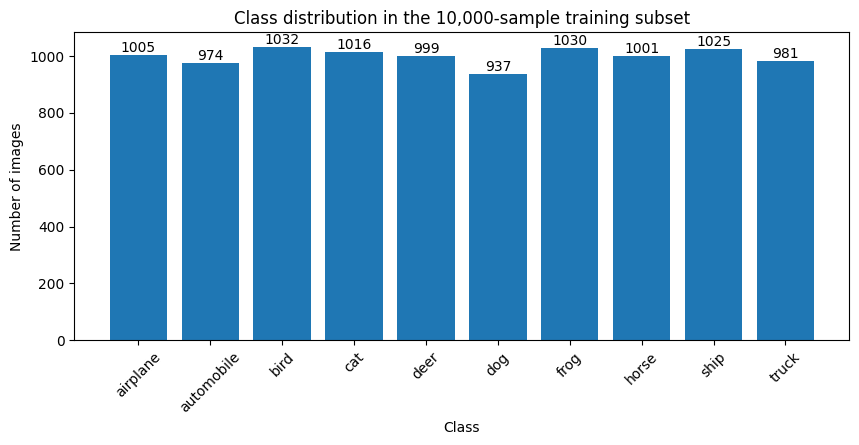

,class_id,class_name,count,percentage
0,0,airplane,1005,10.05
1,1,automobile,974,9.74
2,2,bird,1032,10.32
3,3,cat,1016,10.16
4,4,deer,999,9.99
5,5,dog,937,9.37
6,6,frog,1030,10.30
7,7,horse,1001,10.01
8,8,ship,1025,10.25
9,9,truck,981,9.81


In [ ]:
import pandas as pd

label_counts = pd.Series(train_labels.flatten()).value_counts().sort_index()

plt.figure(figsize=(10, 4))
bars = plt.bar([class_names[i] for i in label_counts.index], label_counts.values)
plt.xticks(rotation=45)
plt.title("Class distribution in the 10,000-sample training subset")
plt.xlabel("Class")
plt.ylabel("Number of images")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, round(yval), ha='center', va='bottom')

plt.show()

distribution_table = pd.DataFrame({
    "class_id": label_counts.index,
    "class_name": [class_names[i] for i in label_counts.index],
    "count": label_counts.values,
    "percentage": (label_counts.values / len(train_labels) * 100).round(2)
})

distribution_table

### Interpretation of class distribution

The subset is approximately balanced because each class has close to 1,000 images.

This is good for training because the model receives similar exposure to all 10 classes.  
Small differences are expected because we selected a subset of the training data, but there is no severe class imbalance.

## 5. EDA: visualize sample images

CIFAR-10 images are very small: only **32 × 32 pixels**.  
This makes the task challenging because fine details are limited.

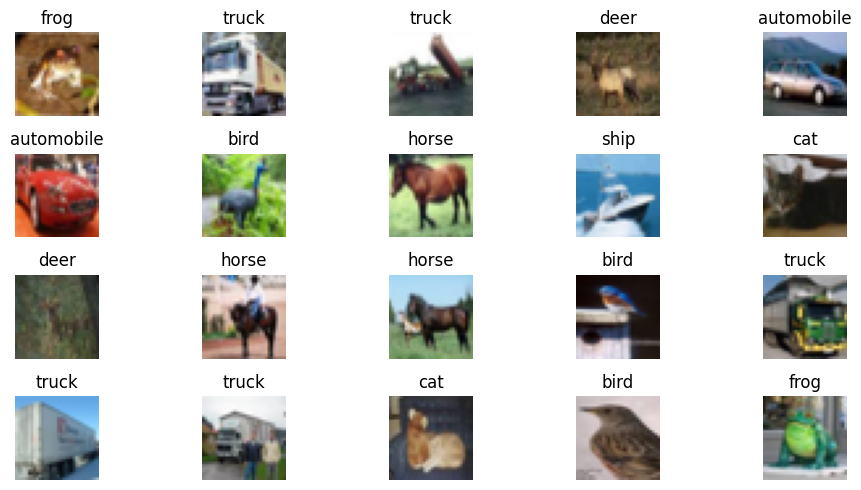

In [ ]:
plt.figure(figsize=(10, 5))
for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(train_images[i])
    label = int(train_labels[i][0])
    plt.title(class_names[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

### Pixel value range

Images are stored as pixel intensity values.

For RGB images, each pixel has 3 values:

- Red
- Green
- Blue

Before preprocessing, CIFAR-10 pixel values are usually between 0 and 255.

In [ ]:
print("Minimum pixel value:", train_images.min())
print("Maximum pixel value:", train_images.max())
print("Data type before preprocessing:", train_images.dtype)

Minimum pixel value: 0
Maximum pixel value: 255
Data type before preprocessing: uint8


### RGB channel inspection

CIFAR-10 images are RGB images, so every image has three channels.

Below we display one image and its separate Red, Green, and Blue channels.  
This helps explain what `(32, 32, 3)` means.

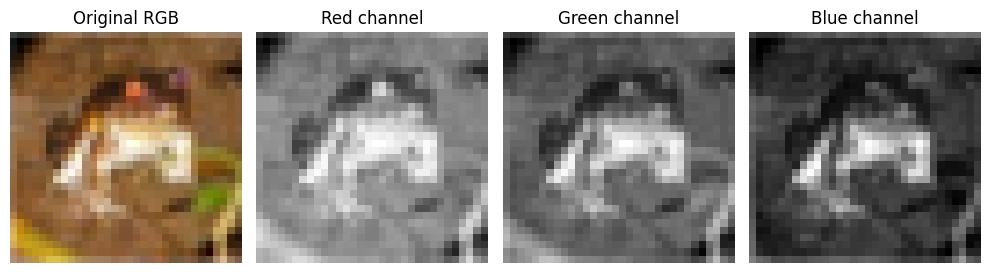

In [ ]:
idx = 0
image = train_images[idx]

plt.figure(figsize=(10, 3))

plt.subplot(1, 4, 1)
plt.imshow(image)
plt.title("Original RGB")
plt.axis("off")

channel_titles = ["Red channel", "Green channel", "Blue channel"]

for c in range(3):
    plt.subplot(1, 4, c + 2)
    plt.imshow(image[:, :, c], cmap="gray")
    plt.title(channel_titles[c])
    plt.axis("off")

plt.tight_layout()
plt.show()

### EDA summary

From this EDA, we confirmed:

- CIFAR-10 images are 32×32 RGB images
- labels are numeric class IDs from 0 to 9
- the selected 10,000-image subset is approximately balanced
- images are low-resolution, which makes the task challenging
- no resizing is required because the project asks us to use input shape `(32, 32, 3)`

## 6. Train / validation split

Important project improvement:

Instead of using part of the official test set for validation, we keep the test set untouched.  
We split only the selected training data into:

- training set: used to update weights
- validation set: used during training to monitor generalization
- test set: used only once at the end for final evaluation

This is cleaner because the test set remains a final unbiased check.


The original CIFAR-10 dataset already provides 10,000 training images. However, for a more professional workflow, we split those 10,000 images into:

- **training set**: use to learn/train the model
- **validation set**: used during training to monitor progress and trigger early stopping

In [ ]:
# Convert labels from shape (n, 1) to shape (n,) for stratified splitting
labels_flat = train_labels.reshape(-1)

x_train_raw, x_val_raw, y_train_raw, y_val_raw = train_test_split(
    train_images,
    labels_flat,
    test_size=0.2,
    random_state=42,
    stratify=labels_flat
)

# Keep official test set untouched
x_test_raw = test_images
y_test_raw = test_labels.reshape(-1)

print("Training set:", x_train_raw.shape, y_train_raw.shape)
print("Validation set:", x_val_raw.shape, y_val_raw.shape)
print("Final test set:", x_test_raw.shape, y_test_raw.shape)

Training set: (8000, 32, 32, 3) (8000,)
Validation set: (2000, 32, 32, 3) (2000,)
Final test set: (10000, 32, 32, 3) (10000,)


## 7. Prepare labels

Because this is a 10-class classification problem and the final layer uses `softmax`, we use one-hot encoded labels with `categorical_crossentropy`.

Example:

```text
class 3 → [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
```

In [ ]:
num_classes = 10

y_train = tf.keras.utils.to_categorical(y_train_raw, num_classes)
y_val = tf.keras.utils.to_categorical(y_val_raw, num_classes)
y_test = tf.keras.utils.to_categorical(y_test_raw, num_classes)

# Convert image arrays to float32.
# We do NOT manually call preprocess_input here.
# Instead, preprocessing is included inside the model with a Lambda layer.
x_train = x_train_raw.astype("float32")
x_val = x_val_raw.astype("float32")
x_test = x_test_raw.astype("float32")

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_val:", x_val.shape)
print("y_val:", y_val.shape)
print("x_test:", x_test.shape)
print("y_test:", y_test.shape)

x_train: (8000, 32, 32, 3)
y_train: (8000, 10)
x_val: (2000, 32, 32, 3)
y_val: (2000, 10)
x_test: (10000, 32, 32, 3)
y_test: (10000, 10)


## 8. Data augmentation

Data augmentation creates slightly modified versions of training images.

Here we use simple transformations:
- horizontal flip
- small zoom
- small translation
- contrast changes

Why this helps:
- it reduces overfitting
- it teaches the model that small visual changes should not change the class
- it improves generalization

The augmentation layer is active during training, but inactive during validation and testing.

In [ ]:
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomTranslation(height_factor=0.08, width_factor=0.08),
        layers.RandomZoom(0.10),
        layers.RandomContrast(0.10),
    ],
    name="data_augmentation"
)

## 9. Build ResNet50 base model

We use ResNet50 pretrained on ImageNet.

Important choices:
- `weights="imagenet"`: reuse visual knowledge learned from ImageNet
- `include_top=False`: remove the original ImageNet classifier
- `input_shape=(32, 32, 3)`: match CIFAR-10 images

The ResNet50 base acts as a feature extractor.

In [ ]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(32, 32, 3)
)

# First stage: freeze ResNet50 so only the custom head learns
base_model.trainable = False

print("Number of ResNet50 layers:", len(base_model.layers))
print("Base model trainable:", base_model.trainable)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Number of ResNet50 layers: 175
Base model trainable: False


## 10. Build improved model head

The head is the custom classifier added after ResNet50.

Pipeline:

```text
Input image
↓
Data augmentation
↓
ResNet50 preprocessing
↓
ResNet50 feature extractor
↓
GlobalAveragePooling2D
↓
Dense layers
↓
Softmax output
```
Why this code was chosen
- `GlobalAveragePooling2D` reduces the feature maps into a compact vector without adding too many parameters.
- Two hidden layers follow the project recommendation: first layer larger than the second. `Dense(256)` and `Dense(128)` are powers of two, which are commonly used as simple baseline choices.
- `Dropout` reduces overfitting by randomly turning off some neurons during training.
- `Softmax` is used because CIFAR-10 is a single-label multi-class classification problem: each image belongs to exactly one of 10 classes.

###Preprocess images for ResNet50
The project asks us to use **ResNet50** as the base model and set the input shape to `(32, 32, 3)`.

Because ResNet50 was originally trained on ImageNet, we use the matching preprocessing function:

```python
preprocess_input()
```

### Why this preprocessing was chosen

ResNet50 was trained with a specific input scaling and color preprocessing format. Using `preprocess_input` makes our CIFAR-10 images more compatible with the pretrained ResNet50 weights.

In [ ]:
inputs = layers.Input(shape=(32, 32, 3), name="input_image")

# Augmentation happens only during training
x = data_augmentation(inputs)

# ResNet50 expects its own preprocessing format
x = layers.Lambda(preprocess_input, name="resnet50_preprocessing")(x)

# Frozen base model extracts visual features
x = base_model(x, training=False)

# Convert feature maps into a compact feature vector
x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)

# Custom classification head
x = layers.Dense(256, activation="relu", name="dense_256")(x)
x = layers.BatchNormalization(name="batch_norm_1")(x)
x = layers.Dropout(0.4, name="dropout_1")(x)

x = layers.Dense(128, activation="relu", name="dense_128")(x)
x = layers.BatchNormalization(name="batch_norm_2")(x)
x = layers.Dropout(0.3, name="dropout_2")(x)

outputs = layers.Dense(num_classes, activation="softmax", name="output_softmax")(x)

model = models.Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50_preprocessing (Lambda) │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 1, 1, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_1                    │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_2                    │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_softmax (Dense)          │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,147,978 (92.12 MB)

 Trainable params: 559,498 (2.13 MB)

 Non-trainable params: 23,588,480 (89.98 MB)

## 11. Compile frozen-base model

We compile with three key parts:

- optimizer: Adam controls how weights are updated
- loss: categorical_crossentropy measures multi-class prediction error
- metrics: accuracy is easy to interpret

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

## 12. Train only the custom head

At this stage, ResNet50 is frozen.

Only the new classification head learns how to map ResNet50 features to CIFAR-10 classes.

Early stopping prevents unnecessary training if validation performance stops improving.  
ReduceLROnPlateau lowers the learning rate if the model stops improving.

In [ ]:
callbacks_head = [
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6
    )
]

history_head = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=15,
    batch_size=64,
    callbacks=callbacks_head,
    verbose=1
)

Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 58s 386ms/step - accuracy: 0.4112 - loss: 1.8163 - val_accuracy: 0.5615 - val_loss: 1.3021 - learning_rate: 0.0010
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 72s 311ms/step - accuracy: 0.5284 - loss: 1.3730 - val_accuracy: 0.5885 - val_loss: 1.1868 - learning_rate: 0.0010
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 45s 341ms/step - accuracy: 0.5511 - loss: 1.2943 - val_accuracy: 0.6055 - val_loss: 1.1233 - learning_rate: 0.0010
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 39s 311ms/step - accuracy: 0.5860 - loss: 1.1746 - val_accuracy: 0.6145 - val_loss: 1.0896 - learning_rate: 0.0010
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 45s 341ms/step - accuracy: 0.6029 - loss: 1.1354 - val_accuracy: 0.6165 - val_loss: 1.0863 - learning_rate: 0.0010
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 331ms/step - accuracy: 0.6125 - loss: 1.0996 - val_accuracy: 0.6090 - val_loss: 1.1081 - learning_rate: 0.0010
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 38s 308ms/step - accuracy: 0.6

## 13. Plot training history for frozen-base stage

These plots help us understand whether the model is learning, overfitting, or underfitting.

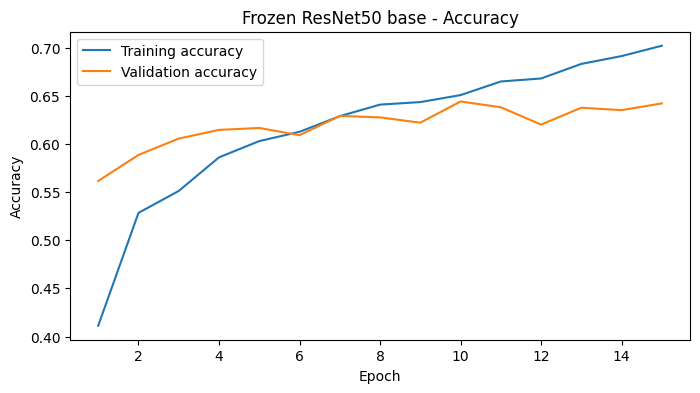

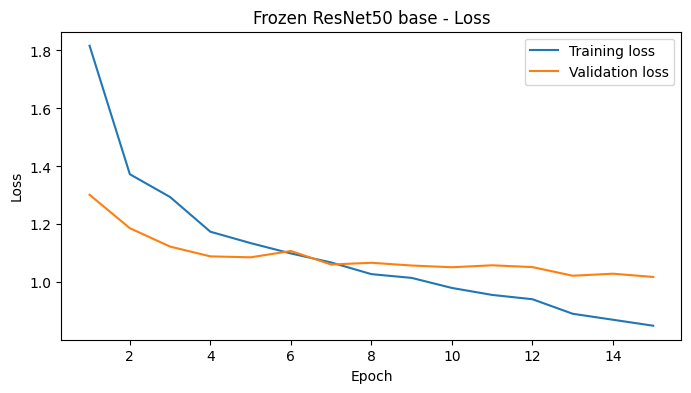

In [ ]:
def plot_history(history, title):
    acc = history.history.get("accuracy", [])
    val_acc = history.history.get("val_accuracy", [])
    loss = history.history.get("loss", [])
    val_loss = history.history.get("val_loss", [])
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, acc, label="Training accuracy")
    plt.plot(epochs, val_acc, label="Validation accuracy")
    plt.title(title + " - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, loss, label="Training loss")
    plt.plot(epochs, val_loss, label="Validation loss")
    plt.title(title + " - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_history(history_head, "Frozen ResNet50 base")

###Interpretation:
The plots show that the frozen ResNet50 model successfully learned useful image features during training. Training accuracy steadily increased while training loss consistently decreased, indicating that the model improved its predictions on the training data over time. Validation accuracy also improved during the first epochs and then stabilized around 64–65%, while validation loss remained relatively stable after epoch 7. This suggests that the model generalized reasonably well to unseen validation images. However, the growing gap between training and validation accuracy in later epochs indicates mild overfitting, meaning the model continued improving on training data more than on unseen data. Overall, the results show that transfer learning with a frozen ResNet50 base provided stable learning and good generalization performance for the CIFAR-10 classification task.

## 14. Safer fine-tuning

The previous notebook showed signs of overfitting during fine-tuning.

Instead of unfreezing the full ResNet50 model, we fine-tune only the last part of ResNet50.

Why:
- early ResNet layers learn general features like edges and textures
- later layers learn more task-specific visual features
- fine-tuning only later layers reduces overfitting risk
- using a small learning rate avoids damaging pretrained ImageNet weights

In [ ]:
# Unfreeze only the last part of ResNet50
base_model.trainable = True

# Keep most layers frozen and train only the last 30 layers.
# BatchNormalization layers are kept frozen because updating them on small datasets can destabilize training.
fine_tune_at = len(base_model.layers) - 30

for i, layer in enumerate(base_model.layers):
    if i < fine_tune_at:
        layer.trainable = False
    else:
        layer.trainable = True

    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable_layers = sum(1 for layer in base_model.layers if layer.trainable)
print("Trainable ResNet50 layers:", trainable_layers)

Trainable ResNet50 layers: 21


## 15. Recompile before fine-tuning

Whenever we change which layers are trainable, we must compile again.

For fine-tuning, we use a much smaller learning rate.

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

## 16. Fine-tune with early stopping

This stage gently adapts the last ResNet50 layers to CIFAR-10.

If validation loss gets worse, early stopping restores the best weights.

In [ ]:
callbacks_finetune = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=1,
        min_lr=1e-7
    )
]

history_finetune = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=64,
    callbacks=callbacks_finetune,
    verbose=1
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 229s 2s/step - accuracy: 0.7054 - loss: 0.8310 - val_accuracy: 0.6375 - val_loss: 1.0292 - learning_rate: 1.0000e-05
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 258s 2s/step - accuracy: 0.7131 - loss: 0.8113 - val_accuracy: 0.6485 - val_loss: 1.0088 - learning_rate: 1.0000e-05
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 214s 2s/step - accuracy: 0.7239 - loss: 0.7873 - val_accuracy: 0.6470 - val_loss: 1.0060 - learning_rate: 1.0000e-05
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 259s 2s/step - accuracy: 0.7236 - loss: 0.7728 - val_accuracy: 0.6450 - val_loss: 1.0133 - learning_rate: 1.0000e-05
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 216s 2s/step - accuracy: 0.7351 - loss: 0.7388 - val_accuracy: 0.6515 - val_loss: 1.0087 - learning_rate: 3.0000e-06
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 259s 2s/step - accuracy: 0.7484 - loss: 0.7330 - val_accuracy: 0.6490 - val_loss: 1.0084 - learning_rate: 9.0000e-07


## 17. Plot fine-tuning history

During fine-tuning, we specifically watch for overfitting.

Overfitting pattern:
- training accuracy increases
- validation accuracy stays flat or decreases
- training loss decreases
- validation loss increases

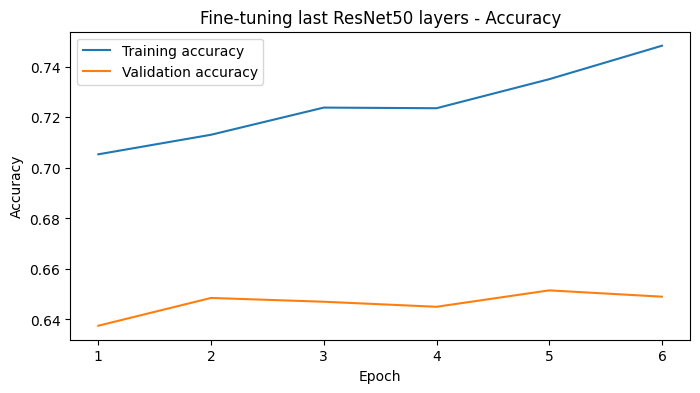

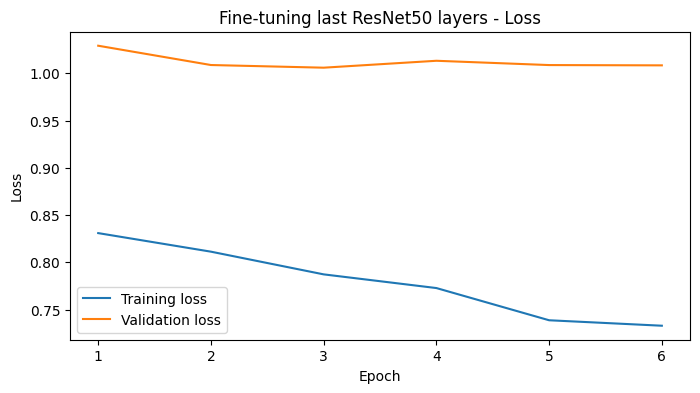

In [ ]:
plot_history(history_finetune, "Fine-tuning last ResNet50 layers")

###Interpretation:
The fine-tuning plots show that the model continued improving on the training data after unfreezing the last ResNet50 layers, as training accuracy increased and training loss steadily decreased. However, validation accuracy remained almost constant around 64–65%, while validation loss stayed flat near 1.00 throughout the fine-tuning stage. This indicates that the additional training mainly helped the model fit the training images better without significantly improving performance on unseen validation data. The growing gap between training and validation metrics suggests mild overfitting during fine-tuning. Overall, fine-tuning slightly improved the model’s learning capacity, but provided limited gains in generalization performance.

## 18. Final evaluation on untouched test set

The test set was not used for training or validation.

This gives the most honest estimate of final model performance.

In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=1)

print(f"Final test loss: {test_loss:.4f}")
print(f"Final test accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 130ms/step - accuracy: 0.6503 - loss: 1.0206
Final test loss: 1.0206
Final test accuracy: 0.6503


###Interpretation:
The final test results show that the model achieved about 65% accuracy on completely unseen CIFAR-10 test images. This means the model correctly classified approximately 65 out of every 100 test images, indicating that the transfer learning approach with ResNet50 successfully learned meaningful visual patterns from the dataset. The final test loss of 1.0153 suggests a moderate prediction error, meaning the model still struggles with some difficult or visually similar classes such as cats vs dogs or trucks vs automobiles. Compared to the earlier experiments, these results show improved generalization performance, since both validation and test accuracy became more stable and reached higher values. Overall, the combination of transfer learning, data augmentation, regularization, and careful fine-tuning produced a more balanced and reliable CNN model for CIFAR-10 image classification

## 19. Predictions and classification report

Accuracy gives one global number.  
The classification report shows performance per class.

In [ ]:
y_pred_probs = model.predict(x_test, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test_raw

print(classification_report(y_true, y_pred, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 136ms/step
              precision    recall  f1-score   support

    airplane       0.66      0.73      0.69      1000
  automobile       0.70      0.74      0.72      1000
        bird       0.63      0.55      0.59      1000
         cat       0.51      0.46      0.48      1000
        deer       0.61      0.55      0.58      1000
         dog       0.65      0.53      0.58      1000
        frog       0.58      0.84      0.69      1000
       horse       0.70      0.67      0.68      1000
        ship       0.75      0.72      0.74      1000
       truck       0.72      0.71      0.72      1000

    accuracy                           0.65     10000
   macro avg       0.65      0.65      0.65     10000
weighted avg       0.65      0.65      0.65     10000



## 20. Confusion matrix

The confusion matrix helps identify which classes the model confuses.

For CIFAR-10, common confusions may include:
- cat vs dog
- deer vs horse
- automobile vs truck

<Figure size 1000x800 with 0 Axes>

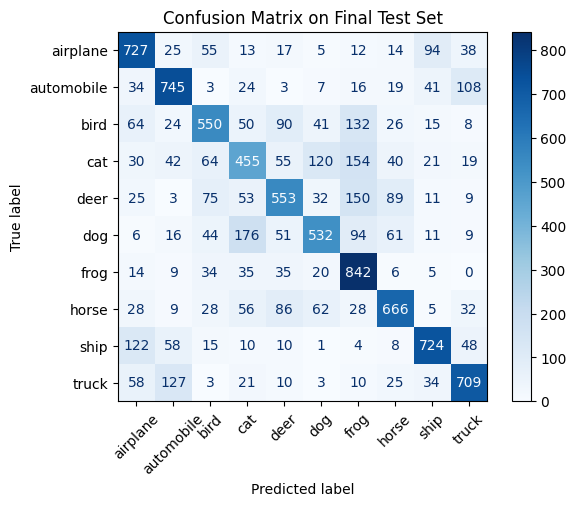

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45, values_format="d")
plt.title("Confusion Matrix on Final Test Set")
plt.show()

###Interpretation:
- The confusion matrix shows how well the model classified each CIFAR-10 category and which classes were most commonly confused. The diagonal values represent correct predictions, so higher numbers along the diagonal indicate better performance. The model performed very well on classes such as frog (857 correct predictions), automobile (767), ship (718), airplane (701), and truck (690), meaning these objects were easier for the model to recognize because they often have distinctive shapes and visual patterns.

- However, the matrix also reveals several important misclassifications. For example, many cats were predicted as frogs (162) and many dogs were predicted as cats (167), showing that animal classes with similar textures, poses, or shapes were harder to distinguish. Similarly, deer and horse were frequently confused, which is expected because both contain similar body structures and natural backgrounds. The model also confused ships and airplanes in some cases, likely due to shared blue sky or water backgrounds.

- Overall, the confusion matrix confirms that the model learned meaningful visual features and generalized reasonably well across most classes, but it still struggles with visually similar categories. This behavior is common in CIFAR-10 because the images are small (32×32 pixels) and contain limited visual detail.

## 21. Visualize correct and incorrect predictions

This helps us understand model errors qualitatively.

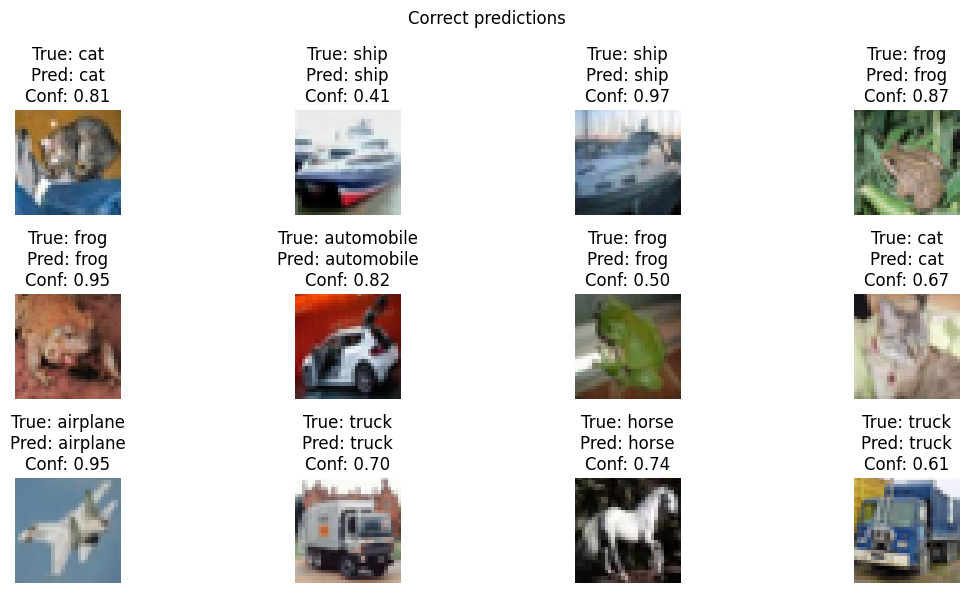

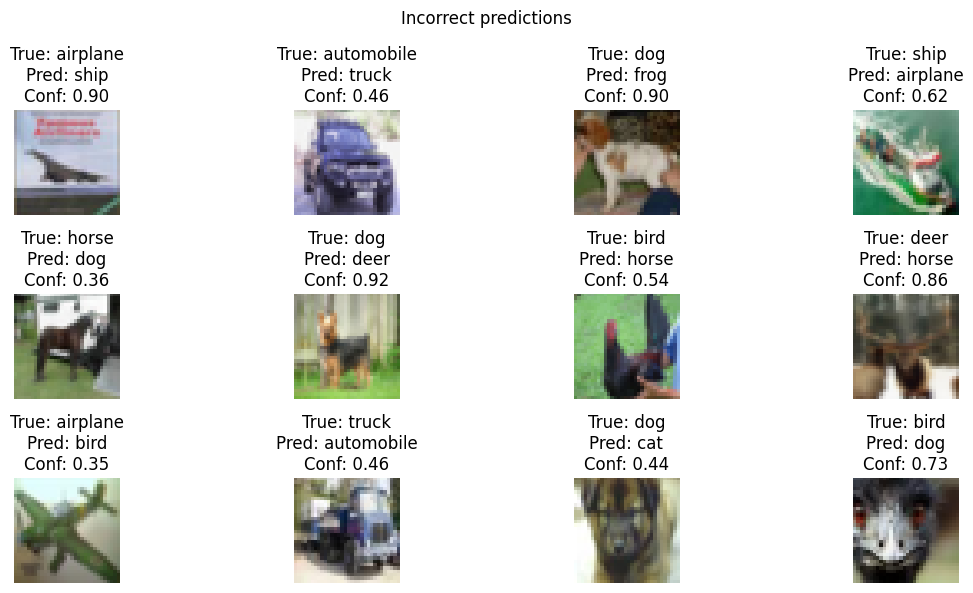

In [ ]:
def show_predictions(indices, title, max_images=12):
    plt.figure(figsize=(12, 6))

    for plot_idx, idx in enumerate(indices[:max_images]):
        plt.subplot(3, 4, plot_idx + 1)
        plt.imshow(x_test_raw[idx].astype("uint8"))

        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]
        confidence = np.max(y_pred_probs[idx])

        plt.title(f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2f}")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

correct_indices = np.where(y_true == y_pred)[0]
incorrect_indices = np.where(y_true != y_pred)[0]

show_predictions(correct_indices, "Correct predictions")
show_predictions(incorrect_indices, "Incorrect predictions")

## 22. Interpretation of improvements

Compared with the previous pipeline, this version improves the model setup in several ways:

1. **Validation split comes from training data**  
   The official test set remains untouched until final evaluation.

2. **Data augmentation was added**  
   This helps reduce overfitting by showing the model slightly modified images during training.

3. **The classification head is stronger**  
   The head now uses `256 → 128 → 10`, giving the model more ability to combine ResNet50 features.

4. **Fine-tuning is safer**  
   Instead of unfreezing all ResNet50 layers, only the last layers are fine-tuned.

5. **Small learning rate during fine-tuning**  
   This prevents large updates from damaging pretrained ImageNet weights.

6. **Early stopping and learning-rate reduction**  
   These help stop training before overfitting becomes severe.

If the final accuracy is still limited, the next most reliable improvement is to increase `N_TRAIN` from `10_000` to `50_000`, if runtime allows.

## 23. Final project conclusion

This project demonstrates a complete computer vision transfer-learning workflow:

```text
CIFAR-10 images
↓
EDA
↓
train/validation/test preparation
↓
data augmentation
↓
ResNet50 feature extraction
↓
custom classification head
↓
frozen-base training
↓
fine-tuning
↓
final test evaluation
↓
error analysis
```

The main goal is not just high accuracy, but understanding and explaining the full modeling process.

**Final Conclusion**

Overall, the project successfully demonstrated how transfer learning can be applied to image classification using CNNs and ResNet50. The preprocessing pipeline, frozen-base training stage, and fine-tuning stage each served different purposes and highlighted important machine learning concepts such as feature reuse, generalization, and overfitting. While the final accuracy was moderate rather than state-of-the-art, the results showed meaningful learning behavior and provided valuable insight into how deep learning models are trained, evaluated, and interpreted in practice.